In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [11]:
df=pd.read_csv("Housing.csv")

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [14]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [15]:
df.shape

(545, 13)

In [16]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

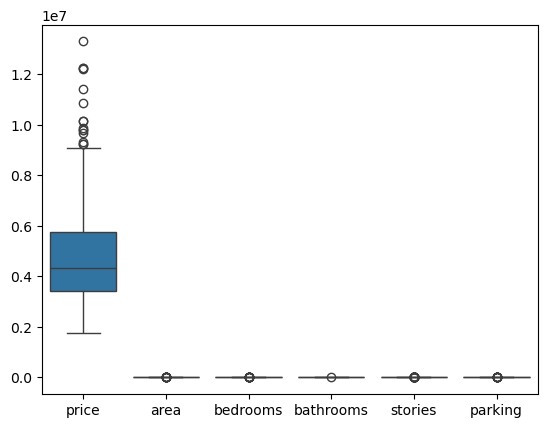

In [17]:
sns.boxplot(df)
plt.show()

In [32]:
Q1=df['price'].quantile(0.25)
Q3=df['price'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['price']>=lower_bound) & (df['price']<=upper_bound)]

In [33]:
Q1=df['area'].quantile(0.25)
Q3=df['area'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['area']>=lower_bound) & (df['area']<=upper_bound)]

In [34]:
Q1=df['bedrooms'].quantile(0.25)
Q3=df['bedrooms'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['bedrooms']>=lower_bound) & (df['bedrooms']<=upper_bound)]

In [35]:
Q1=df['bathrooms'].quantile(0.25)
Q3=df['bathrooms'].quantile(0.75) 
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['bathrooms']>=lower_bound) & (df['bathrooms']<=upper_bound)]

In [36]:
Q1=df['stories'].quantile(0.25)
Q3=df['stories'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['stories']>=lower_bound) & (df['stories']<=upper_bound)]

In [37]:
Q1=df['parking'].quantile(0.25)
Q3=df['parking'].quantile(0.75) 
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['parking']>=lower_bound) & (df['parking']<=upper_bound)]

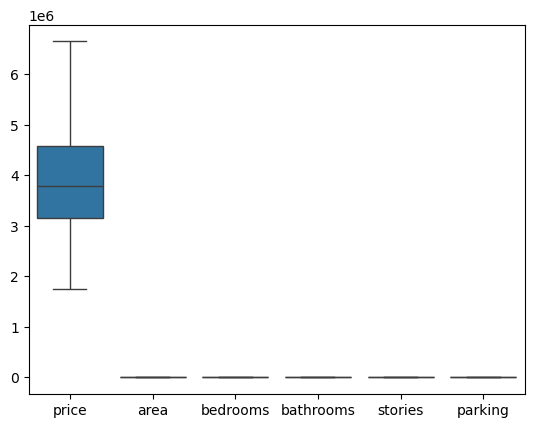

In [38]:
sns.boxplot(df)
plt.show()

In [43]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical columns
df['mainroad'] = le.fit_transform(df['mainroad'])

df['guestroom'] = le.fit_transform(df['guestroom'])

df['basement'] = le.fit_transform(df['basement'])

df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])

df['airconditioning'] = le.fit_transform(df['airconditioning'])

df['prefarea'] = le.fit_transform(df['prefarea'])

df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

In [44]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
74,6650000,4040,3,1,2,1,0,1,1,0,1,0,0
78,6650000,5700,3,1,1,1,1,1,0,1,2,1,0
80,6629000,6000,3,1,2,1,0,0,1,0,1,1,1
84,6510000,3760,3,1,2,1,0,0,1,0,2,0,1
86,6510000,6670,3,1,3,1,0,1,0,0,0,1,2


In [45]:
X = df.drop("price", axis=1)

y = df["price"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(279, 12)
(70, 12)
(279,)
(70,)


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [49]:
print(X_train)

[[-0.49353804 -1.14973833  0.         ... -0.68124519 -0.47861769
  -1.54094237]
 [ 1.08894847 -1.14973833  0.         ...  0.65725768 -0.47861769
  -1.54094237]
 [-0.49353804  0.42269792  0.         ... -0.68124519 -0.47861769
  -1.54094237]
 ...
 [-0.41977808 -1.14973833  0.         ... -0.68124519 -0.47861769
  -0.23020176]
 [ 0.39158153 -1.14973833  0.         ... -0.68124519 -0.47861769
   1.08053886]
 [-0.22531999  0.42269792  0.         ...  0.65725768 -0.47861769
  -0.23020176]]


In [50]:

print(X_test)

[[-0.21861454 -1.14973833  0.          0.69006556  0.46156633  2.6403463
   1.49806076 -0.19280747 -0.55664994 -0.68124519  2.08935029  1.08053886]
 [-1.7943956   0.42269792  0.          0.69006556  0.46156633 -0.3787382
  -0.66752967 -0.19280747 -0.55664994 -0.68124519 -0.47861769  1.08053886]
 [ 0.01607626 -1.14973833  0.         -0.91433687  0.46156633 -0.3787382
  -0.66752967 -0.19280747 -0.55664994 -0.68124519 -0.47861769  1.08053886]
 [-0.41977808  0.42269792  0.         -0.91433687  0.46156633 -0.3787382
  -0.66752967 -0.19280747 -0.55664994 -0.68124519 -0.47861769  1.08053886]
 [ 1.41081013  0.42269792  0.          0.69006556 -2.16653584 -0.3787382
  -0.66752967 -0.19280747  1.79646117  0.65725768 -0.47861769 -0.23020176]
 [-0.38625082 -1.14973833  0.         -0.91433687  0.46156633 -0.3787382
  -0.66752967 -0.19280747 -0.55664994 -0.68124519 -0.47861769  1.08053886]
 [-0.25214179 -1.14973833  0.         -0.91433687  0.46156633 -0.3787382
  -0.66752967 -0.19280747 -0.55664994 -

In [53]:
from sklearn.neighbors import KNeighborsRegressor
knn_regressor = KNeighborsRegressor(
    n_neighbors=5,
    metric='minkowski',
    p=2
)
knn_regressor.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [55]:
y_pred = knn_regressor.predict(X_test)
print(y_pred)

[4781000. 3042200. 3232600. 3255000. 4886000. 2667000. 2938600. 3514000.
 3759000. 3689000. 4326000. 4172000. 4277000. 3738000. 3305400. 5871600.
 3409000. 4632600. 4284000. 3486000. 3113600. 4823000. 3696000. 4060000.
 3892000. 4305000. 3871000. 6097000. 4463200. 4769800. 3563000. 3724000.
 5269600. 4562600. 3120600. 4905600. 5929000. 5439000. 3659600. 3276000.
 2919000. 5150600. 2598400. 3752000. 3155600. 4389000. 4853800. 3409000.
 4608800. 2863000. 3042200. 4326000. 3955000. 4074770. 3073000. 3400600.
 5938800. 4344200. 3864000. 5222000. 4459000. 5551000. 3948000. 3301200.
 3418800. 3871770. 3542000. 3276000. 3892000. 3094000.]


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R2 Score:", r2)

Mean Absolute Error: 584308.0
Mean Squared Error: 574772095940.0
Root Mean Squared Error: 758137.2540246258
R2 Score: 0.5253416760262875
